In [2]:
import pennylane as qml
from pennylane import qchem
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [12]:
PotentialEnergySurf = []
errors = []
fci_energies = []
bond_lengths = [0.5, 0.7, 0.742, 0.9, 1.1, 1.3, 1.5, 1.7, 2.1]

for bl in bond_lengths:
    dataset = qml.data.load(
        "qchem",
        molname = "H2",
        basis = "STO-3G",
        bondlength = bl)[0]
    hamiltonian = dataset.hamiltonian
    fci = dataset.fci_energy
    fci_energies.append(fci)



    dev = qml.device("lightning.qubit", wires=4)

    @qml.qnode(dev)
    def vqe_circuit(params):
        qml.BasisState(np.array([1, 1, 0, 0]), wires=range(4))
        qml.DoubleExcitation(params, wires=range(4))
        return qml.expval(hamiltonian)
    
    params = qml.numpy.array([0.0], requires_grad = True)
    opt = qml.GradientDescentOptimizer(stepsize=0.4)
    energies = []

    for step in range(100):
        params, energy = opt.step_and_cost(vqe_circuit, params)
        energies.append(energy)
    
    print(f'bl={bl}: Final Energy = {energies[-1]} Ha, FCI = {fci} Ha')
    PotentialEnergySurf.append(energies)
    errors.append(np.abs(np.array(energies) - fci))

bl=0.5: Final Energy = [-1.05516074] Ha, FCI = -1.0551607375072107 Ha
bl=0.7: Final Energy = [-1.13618955] Ha, FCI = -1.1361895496530567 Ha
bl=0.742: Final Energy = [-1.13726332] Ha, FCI = -1.1372633205048763 Ha
bl=0.9: Final Energy = [-1.12055996] Ha, FCI = -1.120559964469384 Ha
bl=1.1: Final Energy = [-1.07919244] Ha, FCI = -1.0791924385860894 Ha
bl=1.3: Final Energy = [-1.03518571] Ha, FCI = -1.035185713956801 Ha
bl=1.5: Final Energy = [-0.99814886] Ha, FCI = -0.9981488619840654 Ha
bl=1.7: Final Energy = [-0.97142631] Ha, FCI = -0.9714263137788843 Ha
bl=2.1: Final Energy = [-0.94437452] Ha, FCI = -0.9443745249874615 Ha


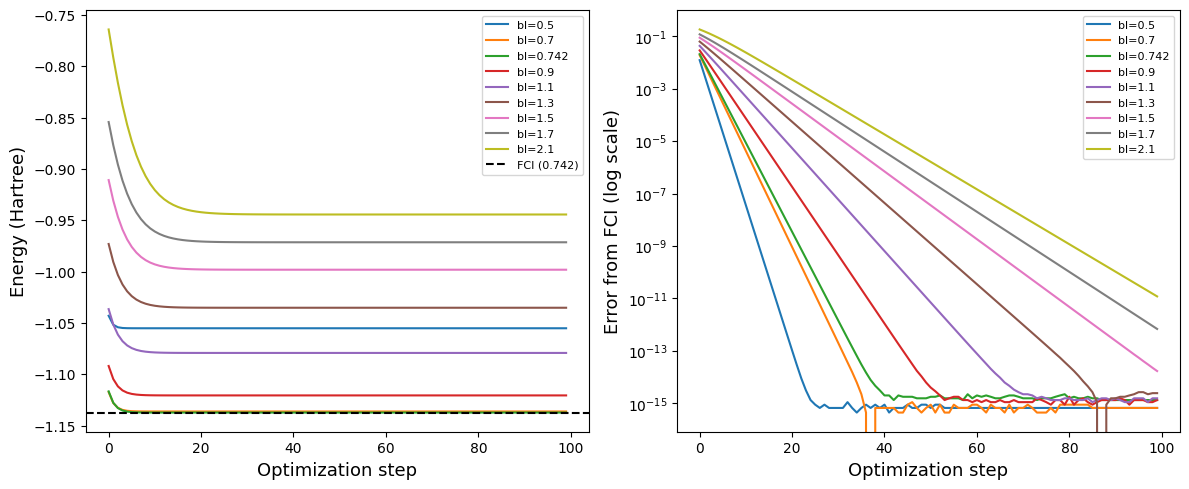

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot energy convergence for each bond length
for i, bl in enumerate(bond_lengths):
    ax1.plot(range(100), PotentialEnergySurf[i], label=f'bl={bl}')
    
ax1.axhline(y=fci_energies[2], color='k', linestyle='--', label='FCI (0.742)')
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.legend(fontsize=8)

# Plot error from FCI for each bond length
for i, bl in enumerate(bond_lengths):
    ax2.semilogy(range(100), errors[i], label=f'bl={bl}')
    
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Error from FCI (log scale)", fontsize=13)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()